# Importando Dados

In [8]:
!pip install pydytuesday -q
import pydytuesday
import pandas as pd

import matplotlib.pyplot as plt

pd.set_option('display.max_rows', 500)

# Download files from the week, which you can then read in locally
pydytuesday.get_date('2026-06-16')

# Option 2: Read directly from GitHub and assign to an object

england_wales_names = pd.read_csv('https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2026/2026-06-16/england_wales_names.csv')
ni_names = pd.read_csv('https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2026/2026-06-16/ni_names.csv')
scotland_names = pd.read_csv('https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2026/2026-06-16/scotland_names.csv')

Trying to fetch README from: https://raw.githubusercontent.com/rfordatascience/tidytuesday/refs/heads/main/data/2026/2026-06-16/readme.md
Successfully fetched README from: https://raw.githubusercontent.com/rfordatascience/tidytuesday/refs/heads/main/data/2026/2026-06-16/readme.md
Successfully saved chart.png to /content/chart.png
Successfully saved cleaning.R to /content/cleaning.R
Successfully saved england_wales_names.csv to /content/england_wales_names.csv
Successfully saved england_wales_names.md to /content/england_wales_names.md
Successfully saved intro.md to /content/intro.md
Successfully saved meta.yaml to /content/meta.yaml
Successfully saved ni_names.csv to /content/ni_names.csv
Successfully saved ni_names.md to /content/ni_names.md
Successfully saved scotland_names.csv to /content/scotland_names.csv
Successfully saved scotland_names.md to /content/scotland_names.md


In [9]:
df_1 = scotland_names.copy()
df_2 = england_wales_names.copy()
df_3 = ni_names.copy()

df_1['Country'] = "Escócia"
df_2['Country'] = "Inglaterra e País de Gales"
df_3['Country'] = "Irlanda do Norte"

df = pd.concat([df_1, df_2, df_3])
df.sample(10)

,Year,Sex,Name,Number,Rank,Country
265220,2013,Girl,Lexia,9.0,2649.0,Inglaterra e País de Gales
139606,2022,Boy,Habeeb,4.0,4002.0,Inglaterra e País de Gales
273900,2014,Girl,Neva,6.0,3514.0,Inglaterra e País de Gales
50214,2023,Boy,Ripley,NaN,NaN,Irlanda do Norte
345347,2024,Girl,Harper-Lilly,3.0,5892.0,Inglaterra e País de Gales
26437,2011,Boy,Braeden,NaN,NaN,Irlanda do Norte
290780,2016,Girl,Viviana,11.0,2367.0,Inglaterra e País de Gales
32890,2004,Boy,Demari,3.0,3651.0,Inglaterra e País de Gales
26676,2011,Boy,Daragh,6.0,261.0,Irlanda do Norte
55969,1997,Girl,NaN,NaN,NaN,Irlanda do Norte


In [10]:
df[["Country", 'Year']].value_counts()

# Pelo range dos dados, o ângulo da análise deve ser algo como o legado dos Beatles em nomes de bebês, ao invés do Boom da Beatlemania (1964-66).
# Além disso, os bancos e cada país só compartilham os anos a partir de 1997
# Pontos no tempo interessantes a investigar:
# 1980: assassinato de John Lennon
# 2001: morte de George Harrison
# 2023: "Now and Then" (última "nova" música dos Beatles, usando IA)

Country                     Year
Inglaterra e País de Gales  2024    14298
                            2012    13923
                            2023    13814
                            2016    13761
                            2017    13679
                            2011    13658
                            2013    13592
                            2015    13548
                            2022    13545
                            2021    13532
                            2018    13473
                            2014    13472
                            2010    13421
                            2019    13305
                            2020    13134
                            2009    13127
                            2008    13047
                            2007    12501
                            2006    11805
                            2005    11222
                            2004    10804
                            2003    10270
                            2002     9599
 

# Análise

In [11]:
# Nomes dos integrantes:
df_beatles = df.copy()
df_beatles = df_beatles[df_beatles['Name'].isin([
    "Paul",
    "Ringo", # Richard
    "John",
    "George"
])]

df_beatles["Name"].value_counts()

Name
George    118
John      111
Paul      110
Ringo       1
Name: count, dtype: int64

In [12]:
# Nomes miscelânia:
df_misc = df.copy()
df_misc = df_misc[df_misc['Name'].isin([
    "Yoko",
    "Linda",
])]

df_misc["Name"].value_counts()

Name
Linda    85
Yoko      1
Name: count, dtype: int64

In [13]:
# Nome derivados de músicas:
df_musicas = df.copy()
df_musicas = df_musicas[df_musicas['Name'].isin([
    "Jude", # Hey Jude, 1968
    "Eleanor", # Eleanor Rigby, 1966
    "Lucy", # Lucy in the Sky With Diamonds, 1967
    "Michelle", # Michelle, 1965
    "Prudence", # Dear Prudence, 1968
    "Rita", # Lovely Rita, 1967
    "Julia", # Julia, 1968
    "Martha", # Martha My Dear, 1968
    "Anna" # Anna (Go to Him), 1963
])]

df_musicas["Name"].value_counts()

Name
Jude        143
Anna        110
Eleanor     110
Julia       110
Lucy        110
Martha      109
Michelle    109
Rita         67
Prudence     29
Name: count, dtype: int64

# Gráfico

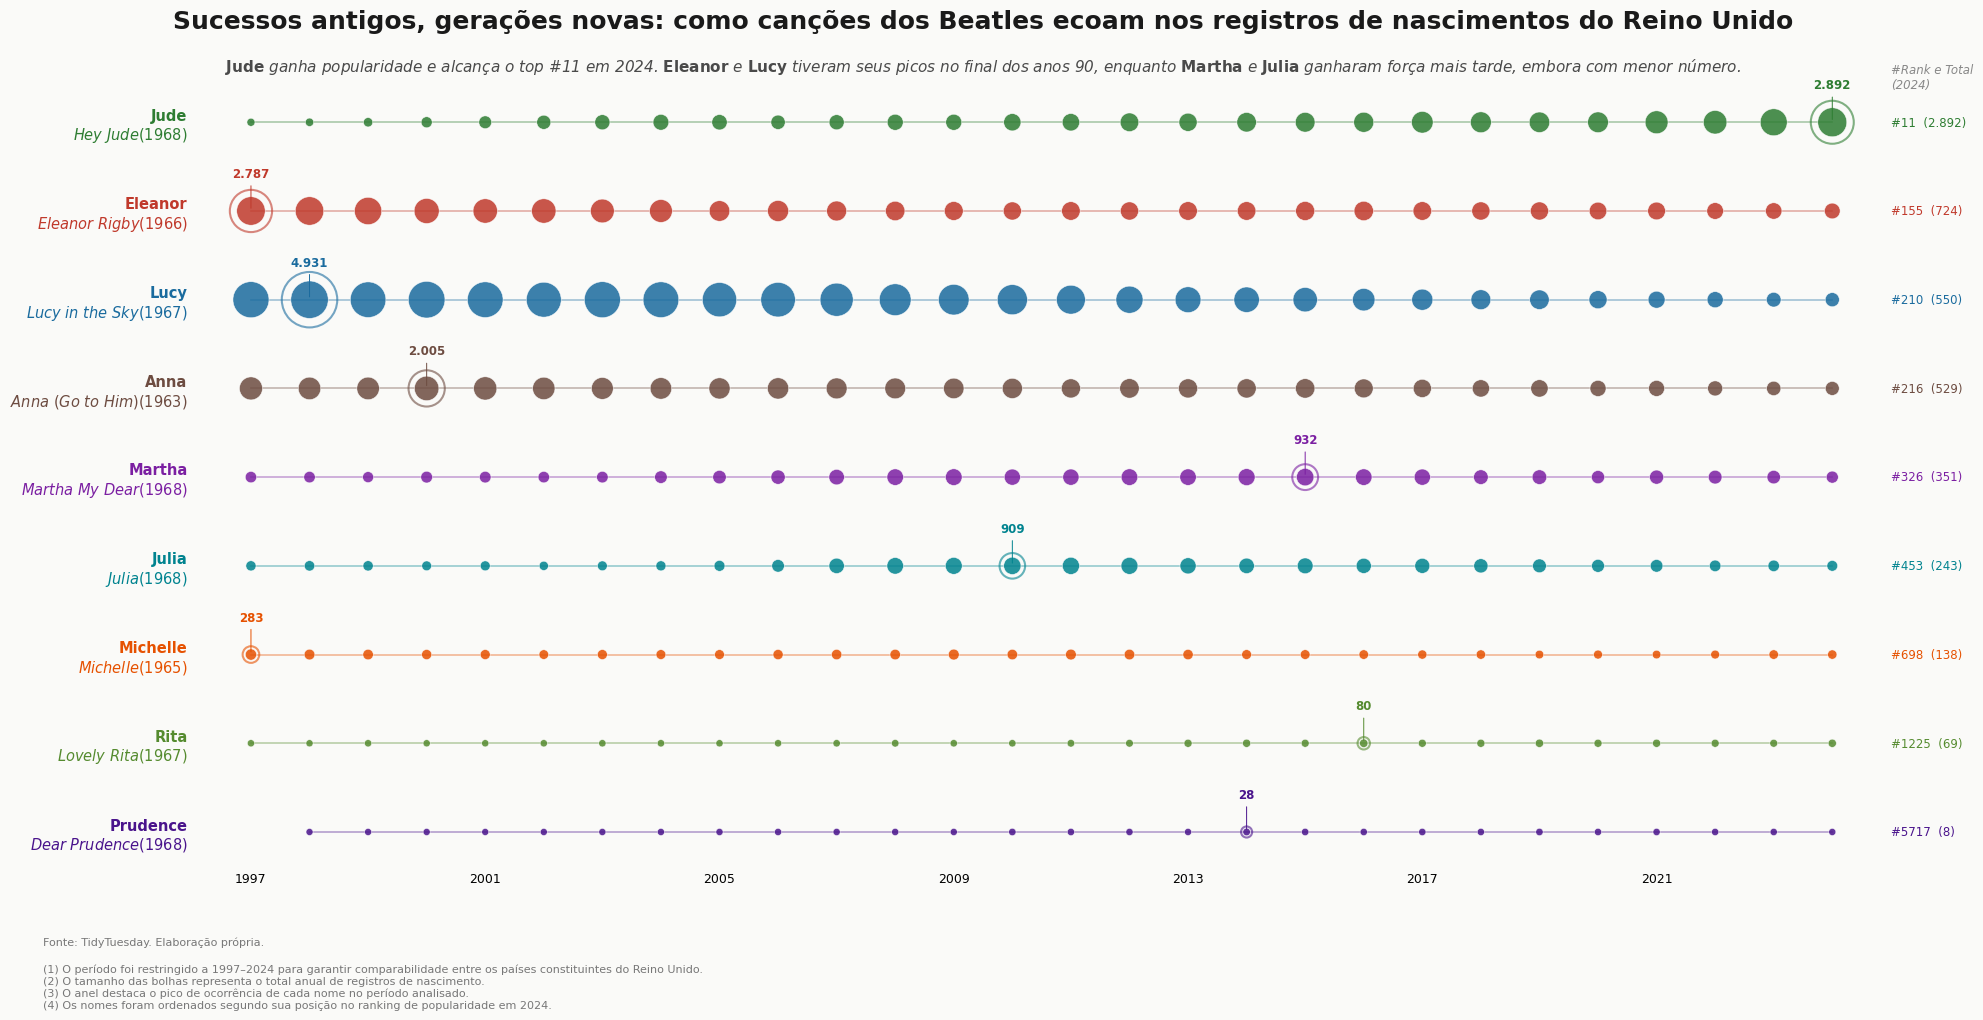

In [16]:
# Configurações
NOMES_FILTRO = ["Lucy", "Eleanor", "Jude", "Anna", "Martha", "Julia", "Michelle", "Rita", "Prudence"]

MUSICAS = {
    "Jude":     ("Hey Jude", 1968),
    "Eleanor":  ("Eleanor Rigby", 1966),
    "Lucy":     ("Lucy in the Sky", 1967),
    "Michelle": ("Michelle", 1965),
    "Prudence": ("Dear Prudence", 1968),
    "Rita":     ("Lovely Rita", 1967),
    "Julia":    ("Julia", 1968),
    "Martha":   ("Martha My Dear", 1968),
    "Anna":     ("Anna (Go to Him)", 1963),
}

PALETA = {
    "Lucy":     "#1a6b9e",
    "Eleanor":  "#c0392b",
    "Jude":     "#2e7d32",
    "Anna":     "#6d4c41",
    "Martha":   "#7b1fa2",
    "Julia":    "#00838f",
    "Michelle": "#e65100",
    "Rita":     "#558b2f",
    "Prudence": "#4a148c",
}

ANO_INICIO = 1997
ANO_FIM = 2024

# Dados
df_musicas = df[
    (df['Name'].isin(NOMES_FILTRO)) &
    (df['Year'] >= ANO_INICIO) &
    (df['Year'] <= ANO_FIM)
].copy()

df_g = (
    df_musicas
    .groupby(["Name", "Year"], as_index=False)["Number"]
    .sum()
    .rename(columns={"Number": "Total"})
)

df_total = (
    df[
        (df['Year'] >= ANO_INICIO) &
        (df['Year'] <= ANO_FIM)
      ].groupby(['Year', 'Name'], as_index=False)['Number']
      .sum()
)

df_total['Overall_Rank'] = df_total.groupby('Year')['Number'].rank(method='min', ascending=False)

max_counts = (
    df_g.loc[df_g.groupby('Name')['Total'].idxmax()]
    .set_index('Name')[['Year', 'Total']]
    .to_dict('index')
)

ranks_2024 = (
    df_total[
        (df_total['Year'] == 2024) &
        (df_total['Name'].isin(NOMES_FILTRO))
    ]
    .set_index('Name')['Overall_Rank']
    .apply(lambda x: f"#{int(x)}")
    .to_dict()
)

ranking_2024_order = (
    df_total[
        (df_total['Year'] == 2024) &
        (df_total['Name'].isin(NOMES_FILTRO))
    ]
    .sort_values('Overall_Rank')
    ['Name']
    .tolist()
)

NOMES_ORDENADOS = ranking_2024_order
NOMES_ORDENADOS = ranking_2024_order[::-1]

# Layout
BG = "#fafaf8"
Y_SPACING = 1.5
max_total = df_g['Total'].max()

fig, ax = plt.subplots(figsize=(20, 10))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

for i, name in enumerate(NOMES_ORDENADOS):
    subset = df_g[df_g['Name'] == name].sort_values('Year')
    if subset.empty:
        continue

    color = PALETA[name]
    y = i * Y_SPACING

    song, release_year = MUSICAS[name]
    if df_g['Year'].min() <= release_year <= df_g['Year'].max():
        ax.axvline(
            release_year,
            ymin=(y - 0.4) / (len(NOMES_ORDENADOS) * Y_SPACING),
            ymax=(y + 0.4) / (len(NOMES_ORDENADOS) * Y_SPACING),
            color=color, alpha=0.25, linewidth=12,
            solid_capstyle='round', clip_on=False
        )

    ax.plot(
        subset['Year'], [y] * len(subset),
        color=color, linewidth=1.2, alpha=0.4, zorder=1
    )

    # Bolhas proporcionais ao total anual
    sizes = (subset['Total'] / max_total) * 700 + 25
    ax.scatter(
        subset['Year'], [y] * len(subset),
        s=sizes, color=color, alpha=0.85,
        edgecolors='white', linewidth=0.4, zorder=2
    )

    # Marcação do pico: anel externo + rótulo com seta
    info = max_counts.get(name)
    if info:
        px, py_val = int(info['Year']), int(info['Total'])
        peak_size = (py_val / max_total) * 700 + 25

        # Anel ao redor da bolha do pico
        ax.scatter(
            px, y, s=peak_size * 2.2,
            facecolors='none', edgecolors=color,
            linewidth=1.5, alpha=0.6, zorder=3
        )

        # Rótulo do pico com seta curta
        ax.annotate(
            f"{py_val:,}".replace(",", "."),
            xy=(px, y),
            xytext=(px, y + 0.52),
            fontsize=8.5, ha='center', va='bottom',
            color=color, fontweight='bold',
            arrowprops=dict(arrowstyle='-', color=color, lw=0.7),
            zorder=5
        )

    # Rank e total de 2024 na margem direita
    rank_str = ranks_2024.get(name, "")
    count_2024_df = df_total[(df_total['Year'] == 2024) & (df_total['Name'] == name)]
    count_2024 = int(count_2024_df['Number'].iloc[0]) if not count_2024_df.empty else 0
    if rank_str:
        ax.text(
            2025, y,
            f"{rank_str}  ({count_2024:,})".replace(",", "."),
            fontsize=8.5, va='center', ha='left',
            color=color,
        )

# Eixo Y: nome + música + ano de lançamento
yticks = [i * Y_SPACING for i in range(len(NOMES_ORDENADOS))]
ax.set_yticks(yticks)
ylabels = [
    f"{n}\n$\\it{{{MUSICAS[n][0].replace(' ', '\\ ')} ({MUSICAS[n][1]})}}$"
    for n in NOMES_ORDENADOS
]
ax.set_yticklabels(ylabels, fontsize=10.5)

for tick, name in zip(ax.get_yticklabels(), NOMES_ORDENADOS):
    tick.set_color(PALETA[name])
    tick.set_fontweight('bold')


# Eixo X
ax.set_xlim(1996, 2026)
ax.set_xticks(range(1997, 2025, 4))
ax.tick_params(axis='x', labelsize=9, length=0)
ax.tick_params(axis='y', length=0)


# Títulos e notas
ax.text(
    0.45, 1.075,
    "Sucessos antigos, gerações novas: como canções dos Beatles ecoam nos registros de nascimentos do Reino Unido",
    transform=ax.transAxes,
    fontsize=18,
    fontweight='bold',
    color='#1a1a1a',
    ha='center'
)

ax.text(
    0.45, 1.02,
    r"$\it{\bf{Jude}}$ ganha popularidade e alcança o top #11 em 2024. "
    r"$\it{\bf{Eleanor}}$ e $\it{\bf{Lucy}}$ tiveram seus picos no final dos anos 90, "
    r"enquanto $\it{\bf{Martha}}$ e $\it{\bf{Julia}}$ ganharam força mais tarde, embora com menor número.",
    transform=ax.transAxes,
    fontsize=11,
    color='#4a4a4a',
    fontstyle='italic',
    ha='center'
)


ax.text(2025, len(NOMES_ORDENADOS) * Y_SPACING - 0.5,
        "#Rank e Total\n(2024)",
        fontsize=8.5, va='top', ha='left', color='#888888', style='italic')

ax.text(
    -0.085, -0.10,
    "Fonte: TidyTuesday. Elaboração própria.",
    transform=ax.transAxes,
    fontsize=8,
    color="#777777"
)

ax.text(
    -0.085, -0.18,
    "(1) O período foi restringido a 1997–2024 para garantir comparabilidade entre os países constituintes do Reino Unido.\n"
    "(2) O tamanho das bolhas representa o total anual de registros de nascimento.\n"
    "(3) O anel destaca o pico de ocorrência de cada nome no período analisado.\n"
    "(4) Os nomes foram ordenados segundo sua posição no ranking de popularidade em 2024.",
    transform=ax.transAxes,
    fontsize=8,
    color="#777777"
)

for spine in ax.spines.values():
    spine.set_visible(False)
ax.xaxis.grid(False)
ax.yaxis.grid(False)

plt.subplots_adjust(bottom=0.22)
plt.tight_layout()
# plt.savefig("beatles_musicas_melhorado.png", dpi=200, bbox_inches='tight', facecolor=BG)
plt.show()